<a href="https://colab.research.google.com/github/ftmshifa777/Matplotlib-Visualization/blob/main/Data_visualization_California_housing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import pandas as pd

# Load the California Housing training dataset
path = '/content/sample_data/california_housing_train.csv'
df = pd.read_csv(path)

# Display the first few rows of the dataset
display(df.head())

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


### Recommended Column Mappings for Visualizations

Based on the columns in the California Housing dataset (`df.columns`), here are the best suggestions for each graphical representation:

1. **Histogram (Distribution of a single variable)**
   * **Columns**: `median_house_value` or `median_income`
   * **Why**: Perfect for showing the spread, skewness, and frequency of house prices or household earnings.

2. **Scatter Plot (Relationship between two continuous variables)**
   * **Columns**: `median_income` (X-axis) vs. `median_house_value` (Y-axis)
   * **Why**: Classic real estate visualization to see if higher income strongly correlates with higher home values.
   * **Alternative (Geographical Map)**: `longitude` (X-axis) vs. `latitude` (Y-axis) with color based on `median_house_value`.

3. **Boxplot (Identifying distribution range, median, and outliers)**
   * **Columns**: `housing_median_age` (or grouped into age ranges) vs. `median_house_value`
   * **Why**: Great to compare how house values range across different age cohorts.

4. **Bar Chart (Comparison of categories)**
   * **Columns**: Average `median_house_value` grouped by categorical groups.
   * **Why**: Since there are no native categorical text columns in this dataset, we can bin `housing_median_age` into categories (e.g., "New", "Moderate", "Old") and plot their average values.

5. **Pie Chart (Composition of a whole)**
   * **Columns**: Proportion of homes categorized by age or income classes.
   * **Why**: We can categorize `housing_median_age` (e.g., under 15 years, 15–30, and 30+ years) and display their relative proportions.

6. **Line Plot (Trend over an ordered index)**
   * **Columns**: Average `median_house_value` sorted by `housing_median_age`.
   * **Why**: Shows whether there is a steady upward or downward trend in home pricing as houses get older.

7. **Multiple Line Plot (Comparison of trends over an ordered index)**
   * **Columns**: Trends of `total_rooms` and `total_bedrooms` averaged and sorted across `housing_median_age`.
   * **Why**: Shows how both total room and bedroom sizes change relatively across different age groups of housing developments.

In [14]:
df.tail()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
16995,-124.26,40.58,52.0,2217.0,394.0,907.0,369.0,2.3571,111400.0
16996,-124.27,40.69,36.0,2349.0,528.0,1194.0,465.0,2.5179,79000.0
16997,-124.30,41.84,17.0,2677.0,531.0,1244.0,456.0,3.0313,103600.0
16998,-124.30,41.80,19.0,2672.0,552.0,1298.0,478.0,1.9797,85800.0
16999,-124.35,40.54,52.0,1820.0,300.0,806.0,270.0,3.0147,94600.0


In [15]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value'],
      dtype='object')

#Line plot

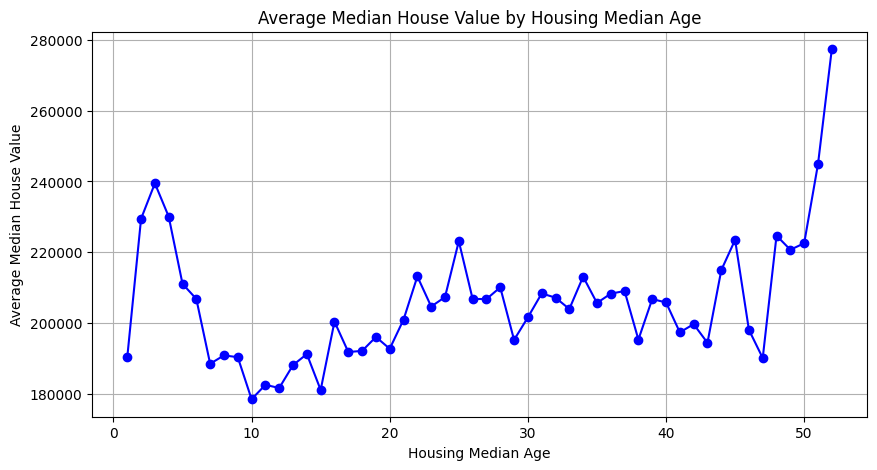

In [16]:
import matplotlib.pyplot as plt

# Group by housing age and calculate the mean house value for each age
age_grouped = df.groupby('housing_median_age')['median_house_value'].mean().reset_index()

# Plot the aggregated trend line
plt.figure(figsize=(10, 5))
plt.plot(age_grouped['housing_median_age'], age_grouped['median_house_value'], marker='o', color='b')
plt.title('Average Median House Value by Housing Median Age')
plt.xlabel('Housing Median Age')
plt.ylabel('Average Median House Value')
plt.grid(True)
plt.show()

#Multiple line plot

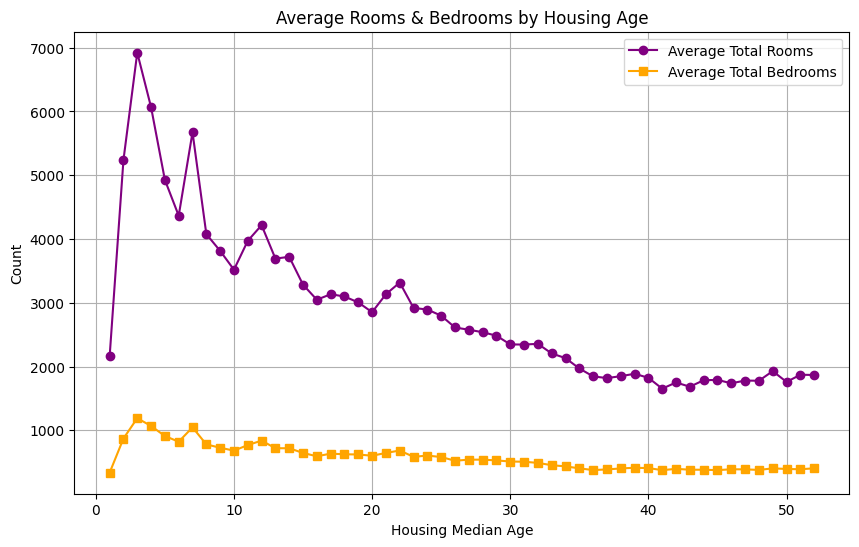

In [17]:
import matplotlib.pyplot as plt

# Group by housing age and calculate the mean for rooms and bedrooms
multi_line_data = df.groupby('housing_median_age')[['total_rooms', 'total_bedrooms']].mean().reset_index()

# Plotting multiple line plot
plt.figure(figsize=(10, 6))
plt.plot(multi_line_data['housing_median_age'], multi_line_data['total_rooms'], label='Average Total Rooms', color='purple', marker='o')
plt.plot(multi_line_data['housing_median_age'], multi_line_data['total_bedrooms'], label='Average Total Bedrooms', color='orange', marker='s')

plt.title('Average Rooms & Bedrooms by Housing Age')
plt.xlabel('Housing Median Age')
plt.ylabel('Count')
plt.legend()
plt.grid(True)
plt.show()

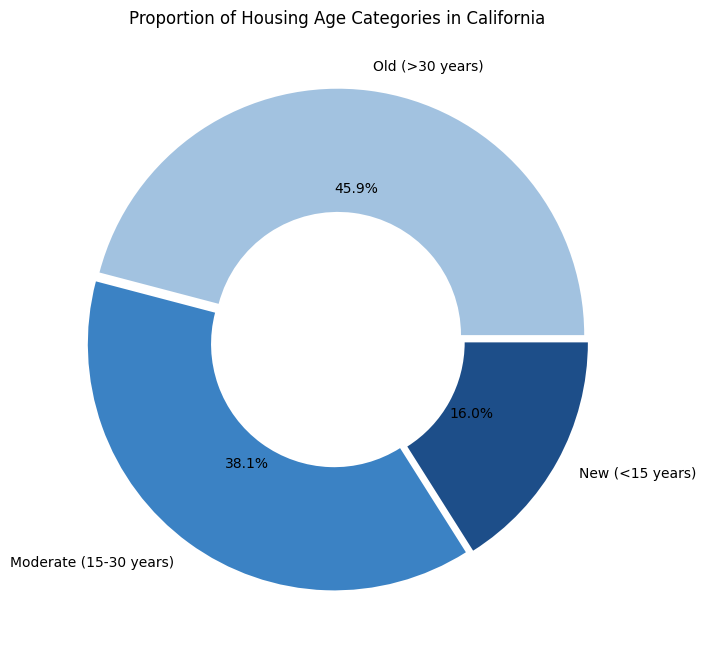

In [24]:
import matplotlib.pyplot as plt

# Bin the housing ages into meaningful categories
age_bins = [0, 15, 30, df['housing_median_age'].max()]
age_labels = ['New (<15 years)', 'Moderate (15-30 years)', 'Old (>30 years)']
df['age_category'] = pd.cut(df['housing_median_age'], bins=age_bins, labels=age_labels)

# Count the frequency of each group
age_counts = df['age_category'].value_counts()

# Plot a clean, legible pie chart
plt.figure(figsize=(8, 8))
plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct='%1.1f%%',
    startangle=0,
    colors=['#a2c2e0', '#3b82c4', '#1d4e89'],
    explode=(0.02, 0.02, 0.02),
    wedgeprops=dict(width=0.5)
)
plt.title('Proportion of Housing Age Categories in California')
plt.show()


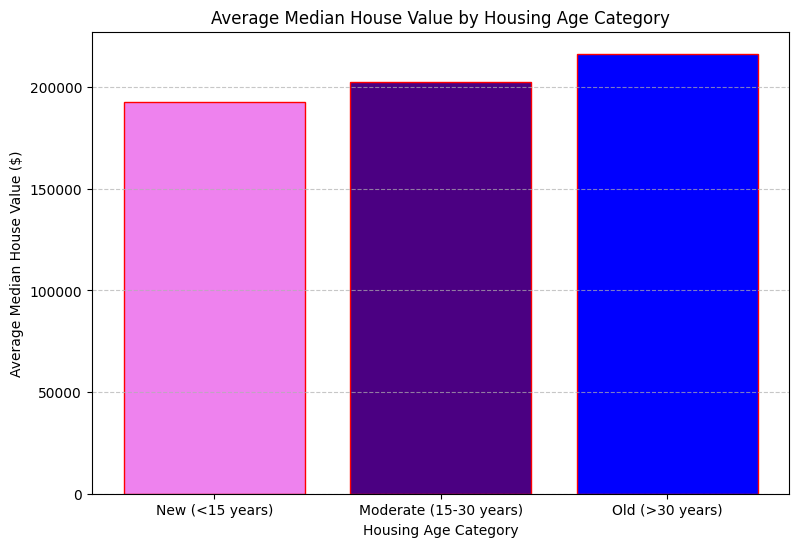

In [20]:
import matplotlib.pyplot as plt

# Calculate the average median house value for each age category
bar_data = df.groupby('age_category', observed=False)['median_house_value'].mean().reset_index()

# Plotting the bar chart using Matplotlib
plt.figure(figsize=(9, 6))
plt.bar(
    bar_data['age_category'].astype(str),
    bar_data['median_house_value'],
    color=['violet','indigo','blue'],
    edgecolor='red',
    width=0.8
)

plt.title('Average Median House Value by Housing Age Category')
plt.xlabel('Housing Age Category')
plt.ylabel('Average Median House Value ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

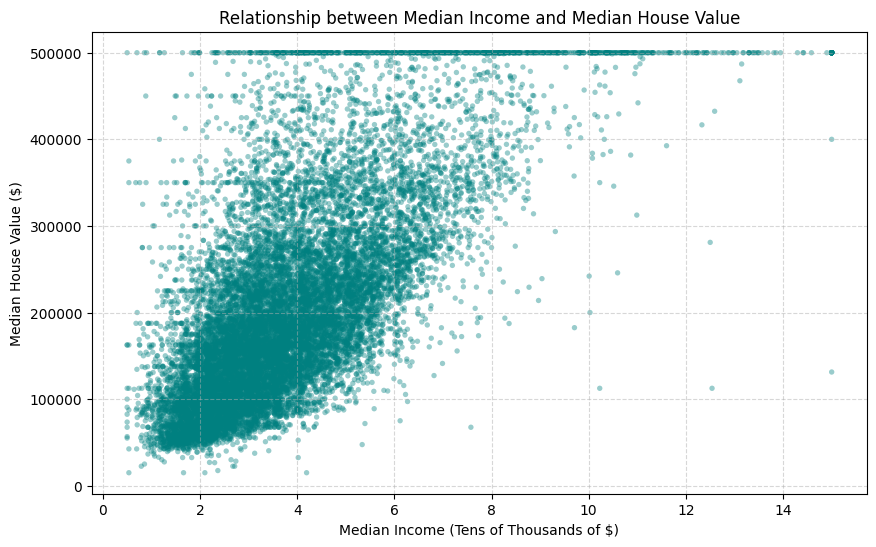

In [21]:
import matplotlib.pyplot as plt

# Plotting a Scatter Plot using Matplotlib
plt.figure(figsize=(10, 6))
plt.scatter(
    df['median_income'],
    df['median_house_value'],
    alpha=0.4,
    color='teal',
    edgecolor='none',
    s=15
)

plt.title('Relationship between Median Income and Median House Value')
plt.xlabel('Median Income (Tens of Thousands of $)')
plt.ylabel('Median House Value ($)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

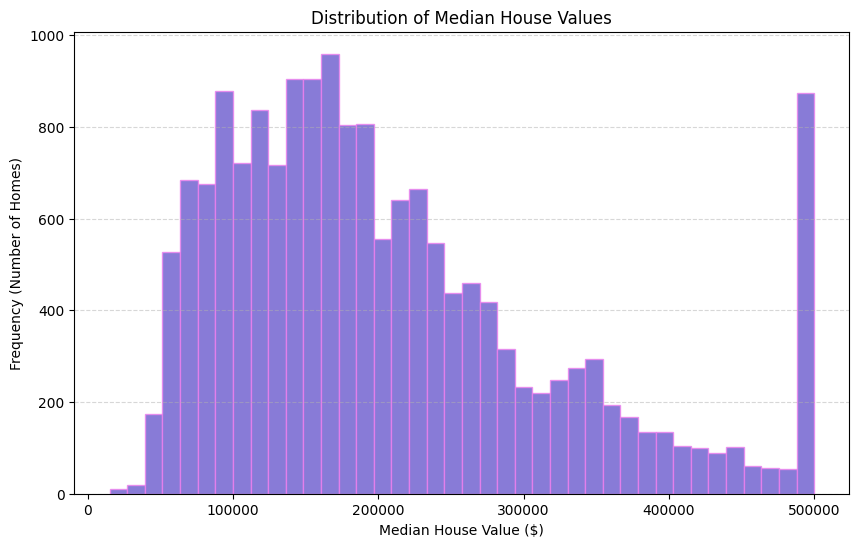

In [22]:
import matplotlib.pyplot as plt

# Plotting a Histogram of Median House Value using Matplotlib
plt.figure(figsize=(10, 6))
plt.hist(
    df['median_house_value'],
    bins=40,
    color='slateblue',
    edgecolor='violet',
    alpha=0.8
)

plt.title('Distribution of Median House Values')
plt.xlabel('Median House Value ($)')
plt.ylabel('Frequency (Number of Homes)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

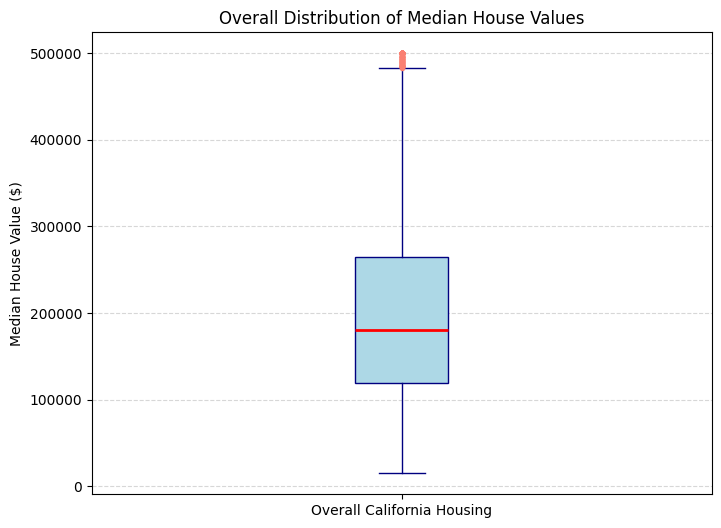

In [23]:
import matplotlib.pyplot as plt

# Prepare data for a single boxplot of overall median house value
overall_house_value = df['median_house_value'].dropna()

# Plotting the overall boxplot using Matplotlib with future-proof 'tick_labels'
plt.figure(figsize=(8, 6))
plt.boxplot(
    overall_house_value,
    tick_labels=['Overall California Housing'],
    patch_artist=True,
    boxprops=dict(facecolor='lightblue', color='navy'),
    medianprops=dict(color='red', linewidth=2),
    whiskerprops=dict(color='navy'),
    capprops=dict(color='navy'),
    flierprops=dict(marker='o', markerfacecolor='salmon', markersize=4, markeredgecolor='none')
)

plt.title('Overall Distribution of Median House Values')
plt.ylabel('Median House Value ($)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()